# NB16 — Auditoria dos Berços de Santos: Classificação e Impacto na Taxa de Ocupação

**Objetivo:** Santos aparece com 55 berços no dataset de Taxa_Ocupacao — muito acima dos outros portos.  
Auditar quais são efectivamente berços de contentores, e avaliar se a mistura infla ou defla a taxa média.

**Input:** `ocupacao_bercos_kpi_2025.csv` (NB13) · `ocupacao_testadia_porto_2025.csv` (NB13)  
**Output:** Tabela classificada + 3 cenários de taxa média + impacto na correlação Spearman

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
import os, warnings

warnings.filterwarnings('ignore')
FIG_DIR = '../outputs/figures/'
CSV_DIR = '../outputs/processed_data/'
os.makedirs(FIG_DIR, exist_ok=True)

plt.rcParams.update({'figure.dpi': 150, 'font.size': 10,
                     'axes.spines.top': False, 'axes.spines.right': False})
print('Setup OK')

Setup OK


---
## 1 — Carregar e Isolar Berços de Santos

In [2]:
kpi_all = pd.read_csv(CSV_DIR + 'ocupacao_bercos_kpi_2025.csv', encoding='utf-8-sig')
corr_df = pd.read_csv(CSV_DIR + 'ocupacao_testadia_porto_2025.csv', encoding='utf-8-sig')

santos = kpi_all[kpi_all['Porto'] == 'Santos'].copy()
print(f'Total berços no dataset: {len(kpi_all)}')
print(f'Berços de Santos: {len(santos)}')
print(f'Outros portos: {len(kpi_all) - len(santos)}')
print()
print('Taxa ocupação média actual de Santos (todos os 55 berços):',
      round(santos['Taxa_Media_Pct'].mean(), 2), '%')

Total berços no dataset: 161
Berços de Santos: 55
Outros portos: 106

Taxa ocupação média actual de Santos (todos os 55 berços): 60.56 %


---
## 2 — Classificação dos 55 Berços

In [3]:
# ── Keywords de classificação ─────────────────────────────────────────────
# Cat A: terminal inequivocamente de contentores
KW_A = [
    'santos brasil', 'btp', 'dp world', 'ecoporto', 'libra terminais',
]
# Cat C: terminal inequivocamente não-container
# (granéis sólidos, líquidos, veículos, estaleiros, químicos)
KW_C = [
    'granéis', 'grão', 'fertiliz', 'barnabé', 'ageo',
    'tev ', 'tev(', 'veículo', 'passageiro',
    'teag', 'tgg ', 'tgg(', 'termag', 'teg ', 'teg(',
    'petróleo', 'petrobras', 'químic', 'petl', 'peta',
    'estaleiro', 'offshore',
]

def classify(row):
    nome = str(row['Nome_Berco']).lower()
    term = str(row['Terminal']).lower()
    combined = nome + ' ' + term

    # Berço inactivo: < 5% taxa (inclui erros de mapeamento)
    if row['Taxa_Media_Pct'] < 5.0:
        return 'C — Inactivo/Irrelevante'

    if any(kw in combined for kw in KW_A):
        return 'A — Claramente contentores'

    if any(kw in combined for kw in KW_C):
        return 'C — Provavelmente não-container'

    return 'B — Provavelmente misto'

santos['Categoria'] = santos.apply(classify, axis=1)

print('Distribuição por categoria:')
print(santos['Categoria'].value_counts())
print()
print('Taxa média por categoria:')
print(santos.groupby('Categoria')['Taxa_Media_Pct'].agg(['mean','count']).round(1))

Distribuição por categoria:
Categoria
B — Provavelmente misto            29
A — Claramente contentores         15
C — Provavelmente não-container     9
C — Inactivo/Irrelevante            2
Name: count, dtype: int64

Taxa média por categoria:
                                 mean  count
Categoria                                   
A — Claramente contentores       62.6     15
B — Provavelmente misto          61.5     29
C — Inactivo/Irrelevante          1.9      2
C — Provavelmente não-container  67.3      9


In [4]:
# ── Tabela completa: 55 berços classificados ─────────────────────────────
tabela_santos = santos[[
    'IDBerco','Nome_Berco','Terminal','Taxa_Media_Pct',
    'Taxa_Carga_Media_Pct','Dias_Acima_80','N_Dias','Status','Categoria'
]].sort_values(['Categoria','Taxa_Media_Pct'], ascending=[True, False]).reset_index(drop=True)

print('=== TABELA COMPLETA — 55 BERÇOS DE SANTOS CLASSIFICADOS ===')
pd.options.display.float_format = '{:.1f}'.format
pd.set_option('display.max_colwidth', 40)
pd.set_option('display.width', 200)
print(tabela_santos[['IDBerco','Nome_Berco','Taxa_Media_Pct',
                      'Dias_Acima_80','N_Dias','Status','Categoria']].to_string(index=False))

=== TABELA COMPLETA — 55 BERÇOS DE SANTOS CLASSIFICADOS ===
    IDBerco                                 Nome_Berco  Taxa_Media_Pct  Dias_Acima_80  N_Dias   Status                       Categoria
    SSZ0812 Cais da Santos Brasil (SSZ 16) - Privativo            83.0            253     365 Vermelho      A — Claramente contentores
    SSZ0813 Cais da Santos Brasil (SSZ 16) - Privativo            82.7            243     365 Vermelho      A — Claramente contentores
    SSZ0811 Cais da Santos Brasil (SSZ 16) - Privativo            80.6            245     365 Vermelho      A — Claramente contentores
    SSZ0108           Cais da BTP (SSZ 41) - Privativo            80.4            228     365 Vermelho      A — Claramente contentores
BRSP0080001                                    Berço 1            80.3            242     365 Vermelho      A — Claramente contentores
    SSZ0109           Cais da BTP (SSZ 41) - Privativo            77.3            202     365  Amarelo      A — Claramente content

---
## 3 — Três Cenários de Taxa Média de Santos

In [5]:
# ── Taxas médias por cenário ──────────────────────────────────────────────
taxa_A55   = santos['Taxa_Media_Pct'].mean()  # todos os 55

cat_A      = santos[santos['Categoria'] == 'A — Claramente contentores']
cat_AB     = santos[santos['Categoria'].isin(['A — Claramente contentores',
                                               'B — Provavelmente misto'])]

taxa_catA  = cat_A['Taxa_Media_Pct'].mean()   # só A
taxa_catAB = cat_AB['Taxa_Media_Pct'].mean()  # A + B

delta_A_vs_55  = taxa_catA  - taxa_A55
delta_AB_vs_55 = taxa_catAB - taxa_A55

print('=== COMPARAÇÃO DAS 3 TAXAS MÉDIAS DE SANTOS ===')
print()
print(f'(1) Todos os 55 berços:              {taxa_A55:.1f}%   (n={len(santos)})')
print(f'(2) Cat. A — Claramente contentores: {taxa_catA:.1f}%   (n={len(cat_A)})')
print(f'(3) Cat. A+B — Contentores + mistos: {taxa_catAB:.1f}%  (n={len(cat_AB)})')
print()
print(f'Δ (A) vs (1): {delta_A_vs_55:+.1f} pp')
print(f'Δ (AB) vs (1): {delta_AB_vs_55:+.1f} pp')
print()

if abs(delta_A_vs_55) > 10:
    print('>>> PROBLEMA DE CLASSIFICAÇÃO CONFIRMADO: diferença > 10pp entre Cat.A e dataset original.')
    if delta_A_vs_55 > 0:
        print('    Os 55 berços DEFLAM a taxa média de Santos (berços não-container têm menor ocupação).')
    else:
        print('    Os 55 berços INFLAM a taxa média de Santos (berços não-container têm maior ocupação).')
elif abs(delta_AB_vs_55) > 10:
    print('>>> PROBLEMA MODERADO: diferença > 10pp entre Cat.A+B e dataset original.')
else:
    print('>>> Diferença < 10pp em todos os cenários — classificação com impacto limitado na taxa média.')
    print('    A inclusão dos berços mistos e não-container não distorce materialmente o resultado de Santos.')

=== COMPARAÇÃO DAS 3 TAXAS MÉDIAS DE SANTOS ===

(1) Todos os 55 berços:              60.6%   (n=55)
(2) Cat. A — Claramente contentores: 62.6%   (n=15)
(3) Cat. A+B — Contentores + mistos: 61.9%  (n=44)

Δ (A) vs (1): +2.1 pp
Δ (AB) vs (1): +1.3 pp

>>> Diferença < 10pp em todos os cenários — classificação com impacto limitado na taxa média.
    A inclusão dos berços mistos e não-container não distorce materialmente o resultado de Santos.


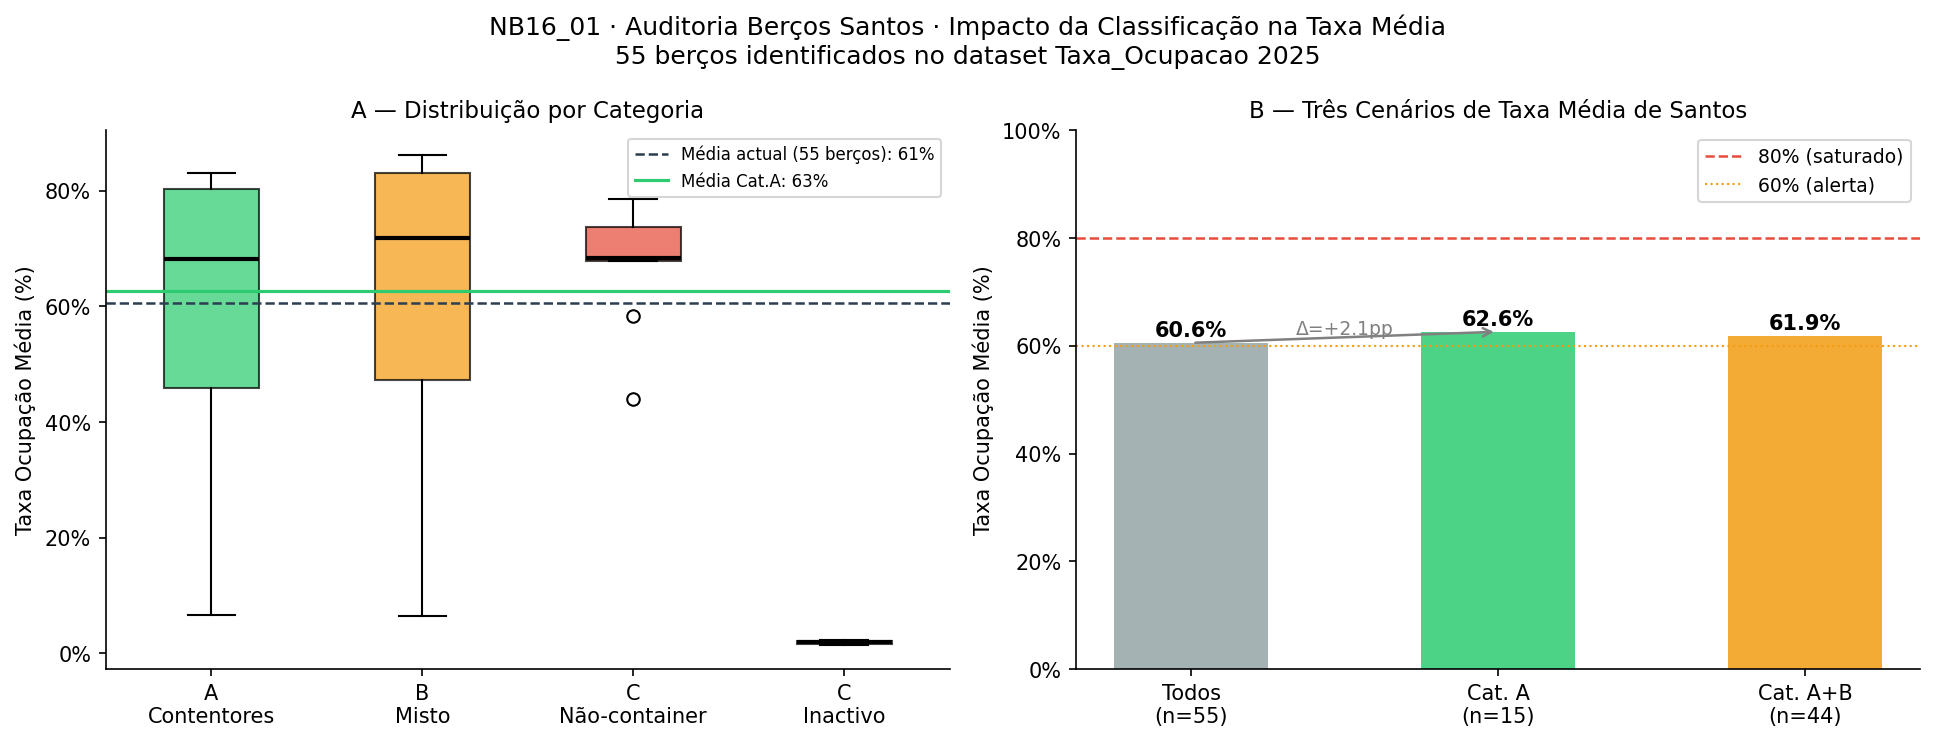

Salvo: nb16_01_auditoria_santos_categorias.png


In [6]:
# ── Figura nb16_01: Distribuição de taxa por categoria ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Painel A: box por categoria
ax0 = axes[0]
cats = ['A — Claramente contentores', 'B — Provavelmente misto', 'C — Provavelmente não-container', 'C — Inactivo/Irrelevante']
cat_colors = ['#2ecc71', '#f39c12', '#e74c3c', '#bdc3c7']
data_bp = [santos[santos['Categoria']==c]['Taxa_Media_Pct'].values for c in cats]
labels_bp = ['A\nContentores', 'B\nMisto', 'C\nNão-container', 'C\nInactivo']

bp = ax0.boxplot([d for d in data_bp if len(d) > 0],
                 labels=[labels_bp[i] for i, d in enumerate(data_bp) if len(d) > 0],
                 patch_artist=True,
                 medianprops=dict(color='black', linewidth=2))
valid_cats = [(c, col) for c, col, d in zip(cats, cat_colors, data_bp) if len(d) > 0]
for patch, (_, col) in zip(bp['boxes'], valid_cats):
    patch.set_facecolor(col)
    patch.set_alpha(0.72)

ax0.axhline(taxa_A55, color='#2C3E50', ls='--', lw=1.2, label=f'Média actual (55 berços): {taxa_A55:.0f}%')
ax0.axhline(taxa_catA, color='#2ecc71', ls='-', lw=1.5, label=f'Média Cat.A: {taxa_catA:.0f}%')
ax0.set_ylabel('Taxa Ocupação Média (%)', fontsize=10)
ax0.set_title('A — Distribuição por Categoria', fontsize=11)
ax0.legend(fontsize=8)
ax0.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

# Painel B: bar comparativo dos 3 cenários
ax1 = axes[1]
cenarios_labels = [f'Todos\n(n=55)', f'Cat. A\n(n={len(cat_A)})', f'Cat. A+B\n(n={len(cat_AB)})']
taxas_cen = [taxa_A55, taxa_catA, taxa_catAB]
bar_cols   = ['#95A5A6', '#2ecc71', '#f39c12']
bars = ax1.bar(cenarios_labels, taxas_cen, color=bar_cols, alpha=0.85, width=0.5)

ax1.axhline(80, color='#e74c3c', ls='--', lw=1.2, label='80% (saturado)')
ax1.axhline(60, color='#f39c12', ls=':',  lw=1.0, label='60% (alerta)')

for bar, val in zip(bars, taxas_cen):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 0.5,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax1.set_ylabel('Taxa Ocupação Média (%)', fontsize=10)
ax1.set_title('B — Três Cenários de Taxa Média de Santos', fontsize=11)
ax1.legend(fontsize=9)
ax1.set_ylim(0, 100)
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

# Anotar delta
ax1.annotate('', xy=(1, taxa_catA), xytext=(0, taxa_A55),
             arrowprops=dict(arrowstyle='->', color='gray', lw=1.2))
ax1.text(0.5, (taxa_catA + taxa_A55)/2 + 0.5,
         f'Δ={delta_A_vs_55:+.1f}pp', ha='center', fontsize=9, color='gray')

fig.suptitle('NB16_01 · Auditoria Berços Santos · Impacto da Classificação na Taxa Média\n'
             '55 berços identificados no dataset Taxa_Ocupacao 2025',
             fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR + 'nb16_01_auditoria_santos_categorias.png', dpi=150)
plt.show()
print('Salvo: nb16_01_auditoria_santos_categorias.png')

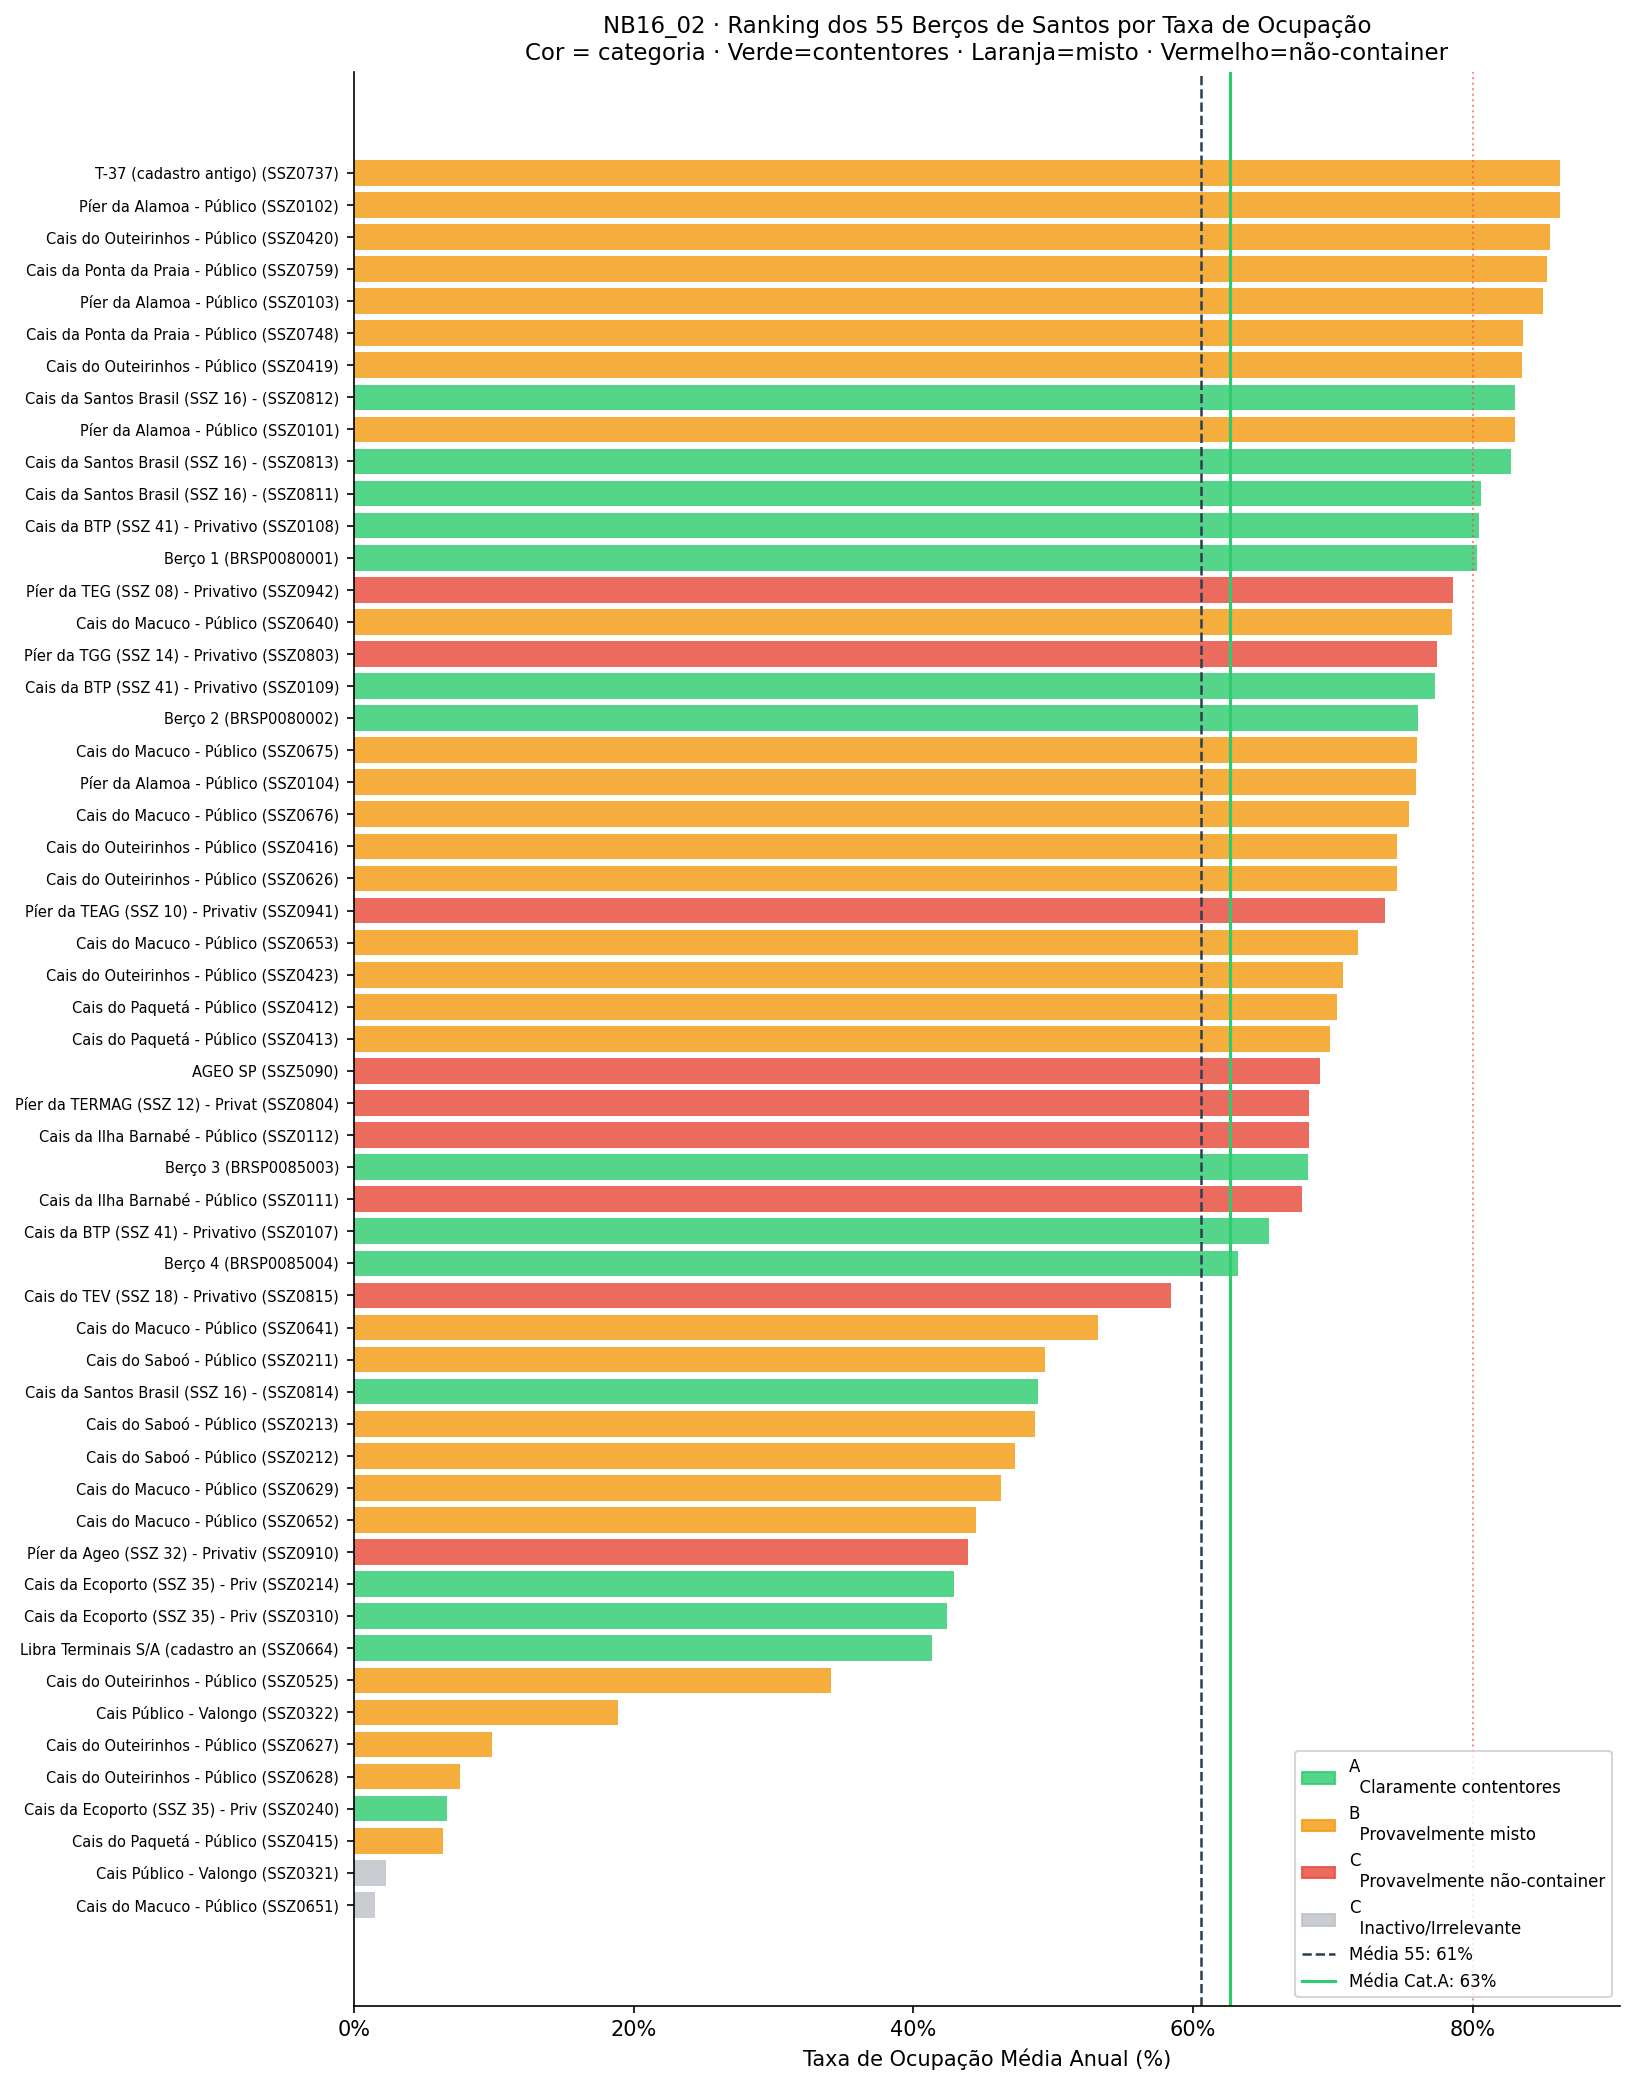

Salvo: nb16_02_ranking_55_bercos_santos.png


In [7]:
# ── Figura nb16_02: Ranking dos 55 berços com cor por categoria ───────────
santos_sorted = santos.sort_values('Taxa_Media_Pct', ascending=True).reset_index(drop=True)
cat_color_map = {
    'A — Claramente contentores':        '#2ecc71',
    'B — Provavelmente misto':           '#f39c12',
    'C — Provavelmente não-container':   '#e74c3c',
    'C — Inactivo/Irrelevante':          '#bdc3c7',
}
bar_colors_rank = [cat_color_map[c] for c in santos_sorted['Categoria']]

fig, ax = plt.subplots(figsize=(11, 14))
ax.barh(range(len(santos_sorted)), santos_sorted['Taxa_Media_Pct'],
        color=bar_colors_rank, alpha=0.82)
ax.set_yticks(range(len(santos_sorted)))
labels_rank = [f"{row['Nome_Berco'][:32]} ({row['IDBerco']})"
               for _, row in santos_sorted.iterrows()]
ax.set_yticklabels(labels_rank, fontsize=7)

ax.axvline(taxa_A55,   color='#2C3E50', ls='--', lw=1.2, label=f'Média 55 berços: {taxa_A55:.0f}%')
ax.axvline(taxa_catA,  color='#2ecc71', ls='-',  lw=1.5, label=f'Média Cat.A: {taxa_catA:.0f}%')
ax.axvline(80, color='#e74c3c', ls=':', lw=1.0, alpha=0.6, label='80% (saturado)')

from matplotlib.patches import Patch
legend_patches = [Patch(color=v, alpha=0.82, label=k.replace(' — ', '\n  ')) for k, v in cat_color_map.items()]
legend_patches += [plt.Line2D([0],[0], color='#2C3E50', ls='--', lw=1.2, label=f'Média 55: {taxa_A55:.0f}%'),
                   plt.Line2D([0],[0], color='#2ecc71', ls='-',  lw=1.5, label=f'Média Cat.A: {taxa_catA:.0f}%')]
ax.legend(handles=legend_patches, fontsize=8, loc='lower right')

ax.set_xlabel('Taxa de Ocupação Média Anual (%)', fontsize=10)
ax.set_title('NB16_02 · Ranking dos 55 Berços de Santos por Taxa de Ocupação\n'
             'Cor = categoria · Verde=contentores · Laranja=misto · Vermelho=não-container',
             fontsize=11)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
plt.tight_layout()
plt.savefig(FIG_DIR + 'nb16_02_ranking_55_bercos_santos.png', dpi=150)
plt.show()
print('Salvo: nb16_02_ranking_55_bercos_santos.png')

---
## 4 — Impacto na Correlação Spearman (NB15)

In [8]:
# ── Substituir taxa de Santos pelos 3 cenários e recalcular ρ ─────────────
def spearman_pair(data, x_col, y_col):
    sub = data.dropna(subset=[x_col, y_col])
    if len(sub) < 3:
        return np.nan, np.nan, len(sub)
    rho, p = stats.spearmanr(sub[x_col], sub[y_col])
    return round(rho, 3), round(p, 3), len(sub)

# Cenário base (NB13): taxa Santos = taxa_A55 já no corr_df
taxa_santos_original = corr_df.loc[corr_df['Porto_Canon'] == 'Santos', 'Taxa_Media_Pct'].values[0]
print(f'Taxa Santos no corr_df (NB13): {taxa_santos_original:.1f}%')
print(f'Taxa Santos calculada aqui (55 berços): {taxa_A55:.1f}%')
print(f'Taxa Santos Cat.A: {taxa_catA:.1f}%')
print(f'Taxa Santos Cat.A+B: {taxa_catAB:.1f}%')
print()

rho_est_base, p_est_base, n_base = spearman_pair(corr_df, 'Taxa_Media_Pct', 'TEstadia_Med')
rho_esp_base, p_esp_base, _      = spearman_pair(corr_df, 'Taxa_Media_Pct', 'TEspera_Med')

# Recalcular com taxa Cat.A
corr_catA = corr_df.copy()
corr_catA.loc[corr_catA['Porto_Canon'] == 'Santos', 'Taxa_Media_Pct'] = taxa_catA
rho_est_catA, p_est_catA, _ = spearman_pair(corr_catA, 'Taxa_Media_Pct', 'TEstadia_Med')
rho_esp_catA, p_esp_catA, _ = spearman_pair(corr_catA, 'Taxa_Media_Pct', 'TEspera_Med')

# Recalcular com taxa Cat.A+B
corr_catAB = corr_df.copy()
corr_catAB.loc[corr_catAB['Porto_Canon'] == 'Santos', 'Taxa_Media_Pct'] = taxa_catAB
rho_est_catAB, p_est_catAB, _ = spearman_pair(corr_catAB, 'Taxa_Media_Pct', 'TEstadia_Med')
rho_esp_catAB, p_esp_catAB, _ = spearman_pair(corr_catAB, 'Taxa_Media_Pct', 'TEspera_Med')

tab_corr = pd.DataFrame([
    {'Cenário Santos':        f'Original NB13 ({taxa_santos_original:.1f}%)',
     'Taxa_Santos_Pct': taxa_santos_original,
     'ρ_TEstadia': rho_est_base, 'p_TEstadia': p_est_base,
     'ρ_TEspera':  rho_esp_base, 'p_TEspera':  p_esp_base},
    {'Cenário Santos':        f'Cat.A — Contentores ({taxa_catA:.1f}%)',
     'Taxa_Santos_Pct': taxa_catA,
     'ρ_TEstadia': rho_est_catA, 'p_TEstadia': p_est_catA,
     'ρ_TEspera':  rho_esp_catA, 'p_TEspera':  p_esp_catA},
    {'Cenário Santos':        f'Cat.A+B — Contentores+Misto ({taxa_catAB:.1f}%)',
     'Taxa_Santos_Pct': taxa_catAB,
     'ρ_TEstadia': rho_est_catAB, 'p_TEstadia': p_est_catAB,
     'ρ_TEspera':  rho_esp_catAB, 'p_TEspera':  p_esp_catAB},
])

print('=== IMPACTO NA CORRELAÇÃO SPEARMAN (n=10 portos) ===')
print(tab_corr[['Cenário Santos','Taxa_Santos_Pct',
                'ρ_TEstadia','p_TEstadia','ρ_TEspera','p_TEspera']].to_string(index=False))
print()

delta_rho_est = rho_est_catA - rho_est_base
delta_rho_esp = rho_esp_catA - rho_esp_base
print(f'Δρ_TEstadia (Cat.A vs Original): {delta_rho_est:+.3f}')
print(f'Δρ_TEspera  (Cat.A vs Original): {delta_rho_esp:+.3f}')
print()
if abs(delta_rho_est) < 0.05 and abs(delta_rho_esp) < 0.05:
    print('→ Impacto NEGLIGÍVEL (<0.05 em ρ): a classificação de Santos não altera o resultado da correlação.')
elif abs(delta_rho_est) < 0.15:
    print('→ Impacto MODERADO: a correcção de Santos muda ρ mas não muda o veredicto qualitativo.')
else:
    print('→ Impacto MATERIAL: a classificação de Santos altera significativamente a correlação.')

Taxa Santos no corr_df (NB13): 60.6%
Taxa Santos calculada aqui (55 berços): 60.6%
Taxa Santos Cat.A: 62.6%
Taxa Santos Cat.A+B: 61.9%

=== IMPACTO NA CORRELAÇÃO SPEARMAN (n=10 portos) ===
                     Cenário Santos  Taxa_Santos_Pct  ρ_TEstadia  p_TEstadia  ρ_TEspera  p_TEspera
              Original NB13 (60.6%)             60.6         0.9         0.0        0.8        0.0
        Cat.A — Contentores (62.6%)             62.6         0.8         0.0        0.8        0.0
Cat.A+B — Contentores+Misto (61.9%)             61.9         0.8         0.0        0.8        0.0

Δρ_TEstadia (Cat.A vs Original): -0.037
Δρ_TEspera  (Cat.A vs Original): +0.012

→ Impacto NEGLIGÍVEL (<0.05 em ρ): a classificação de Santos não altera o resultado da correlação.


---
## 5 — Exportação

In [9]:
# ── CSV 1: Tabela classificada dos 55 berços ─────────────────────────────
tabela_santos.to_csv(CSV_DIR + 'auditoria_bercos_santos_2025.csv',
                     index=False, encoding='utf-8-sig')
print('Salvo: auditoria_bercos_santos_2025.csv')

# ── CSV 2: Impacto na correlação ──────────────────────────────────────────
tab_corr.to_csv(CSV_DIR + 'impacto_classificacao_santos_correlacao.csv',
                index=False, encoding='utf-8-sig')
print('Salvo: impacto_classificacao_santos_correlacao.csv')

print()
print('=== SUMÁRIO FINAL ===')
print(f'Santos — 55 berços auditados:')
for cat, grp in santos.groupby('Categoria'):
    print(f'  {cat:40s}  n={len(grp):2d}  taxa_média={grp["Taxa_Media_Pct"].mean():.1f}%')
print()
print(f'Taxa média Santos:')
print(f'  (1) Todos os 55:        {taxa_A55:.1f}%')
print(f'  (2) Cat.A (contentores): {taxa_catA:.1f}%  Δ={delta_A_vs_55:+.1f}pp')
print(f'  (3) Cat.A+B (c+mistos):  {taxa_catAB:.1f}%  Δ={delta_AB_vs_55:+.1f}pp')
print()
print(f'Os berços não-container/mistos '
      + ('DEFLAM' if delta_A_vs_55 > 0 else 'INFLAM')
      + ' a taxa média de Santos.')

Salvo: auditoria_bercos_santos_2025.csv
Salvo: impacto_classificacao_santos_correlacao.csv

=== SUMÁRIO FINAL ===
Santos — 55 berços auditados:
  A — Claramente contentores                n=15  taxa_média=62.6%
  B — Provavelmente misto                   n=29  taxa_média=61.5%
  C — Inactivo/Irrelevante                  n= 2  taxa_média=1.9%
  C — Provavelmente não-container           n= 9  taxa_média=67.3%

Taxa média Santos:
  (1) Todos os 55:        60.6%
  (2) Cat.A (contentores): 62.6%  Δ=+2.1pp
  (3) Cat.A+B (c+mistos):  61.9%  Δ=+1.3pp

Os berços não-container/mistos DEFLAM a taxa média de Santos.
